In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

df= pd.read_csv('/content/drive/MyDrive/train.csv')



In [11]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [4]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
21258,False
21259,False
21260,False
21261,False


In [5]:
X=df.drop('critical_temp',axis =1)
y= df['critical_temp']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30,random_state=42)

In [13]:


df_feat = pd.DataFrame(X_train ,columns=df.columns[:-1])
df_feat.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence
15443,2,94.987925,97.015283,94.793007,96.840782,0.691096,0.615428,12.164150,37.744717,6.082075,...,4.50,5.000000,4.242641,4.762203,0.636514,0.500402,3,3.000000,1.500000,1.414214
469,4,76.444563,81.456750,59.356672,68.229617,1.199541,1.108189,121.327600,36.950657,43.823354,...,2.25,2.142857,2.213364,2.119268,1.368922,1.309526,1,0.571429,0.433013,0.349927
20125,4,53.172391,51.283005,48.794569,45.843286,1.314758,1.053313,51.931831,24.384535,18.870271,...,3.25,3.010000,2.783158,2.473317,1.265857,0.993345,4,1.626667,1.479020,1.636022
10746,3,186.050000,191.337500,184.194694,189.694734,1.088975,1.002835,56.840000,66.010000,25.380506,...,3.00,3.250000,2.884499,3.130169,1.060857,0.925129,2,1.500000,0.816497,0.829156
11724,2,72.451240,90.001750,69.503737,89.155518,0.652745,0.171167,40.910280,82.618304,20.455140,...,5.50,5.071000,5.477226,5.065145,0.689009,0.288449,1,4.219000,0.500000,0.256825


In [16]:
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor()
dtree.fit(X_train,y_train)


DecisionTreeRegressor()

In [17]:
predictions1 = dtree.predict(X_test)

In [18]:
print('MAE:', mean_absolute_error(y_test, predictions1))
print('MSE:', mean_squared_error(y_test, predictions1))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions1)))
print('r^2:', r2_score(y_test, predictions1))

MAE: 6.321994966456053
MSE: 151.29513621879258
RMSE: 12.300208787609769
r^2: 0.8696513251648785


13976     6.40
1710     91.20
369      38.00
1698     19.00
13540    11.00
         ...  
9260     43.00
13177     4.24
12425     6.43
13908    14.90
533      92.20
Name: critical_temp, Length: 6379, dtype: float64 [12.37454545 84.56621622 28.         ...  6.43       11.7
 92.1       ]


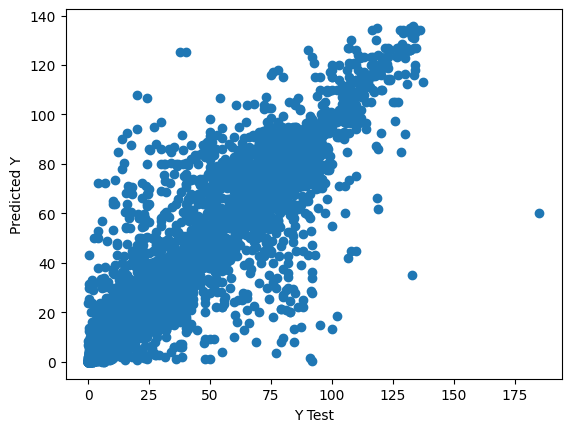

In [19]:
plt.scatter(y_test,predictions1)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
print(y_test, predictions1)

Random Forest


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [22]:
rfr = RandomForestRegressor(n_estimators=400)
rfr.fit(X_train,y_train)
predictions2 = rfr.predict(X_test)


MAE: 5.321787155945763
MSE: 92.36589507183461
RMSE: 9.610717718871708
r^2: 0.920421949287501
13976     6.40
1710     91.20
369      38.00
1698     19.00
13540    11.00
         ...  
9260     43.00
13177     4.24
12425     6.43
13908    14.90
533      92.20
Name: critical_temp, Length: 6379, dtype: float64 [12.37871955 84.69164112 27.796      ...  6.46086607 13.42632083
 91.24381831]


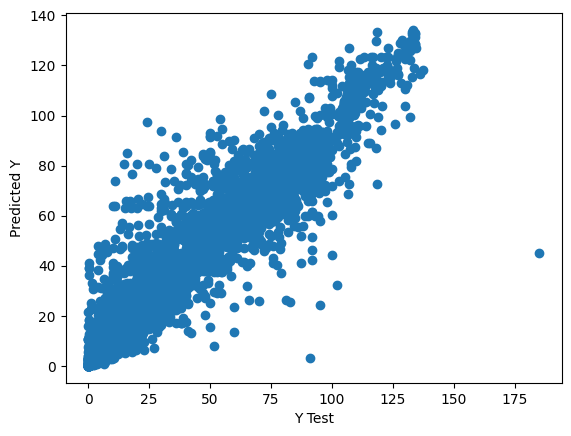

In [23]:
print('MAE:', mean_absolute_error(y_test, predictions2))
print('MSE:', mean_squared_error(y_test, predictions2))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions2)))
print('r^2:', r2_score(y_test, predictions2))
plt.scatter(y_test,predictions2)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
print(y_test, predictions2)

In [24]:
from xgboost import XGBRegressor

In [25]:
xgb =XGBRegressor(n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1)
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
predictions3 = xgb.predict(X_test)

MAE: 5.388000512312398
MSE: 89.0534227913154
RMSE: 9.436812109569386
r^2: 0.9232758174486648
13976     6.40
1710     91.20
369      38.00
1698     19.00
13540    11.00
         ...  
9260     43.00
13177     4.24
12425     6.43
13908    14.90
533      92.20
Name: critical_temp, Length: 6379, dtype: float64 [10.298531 84.96207  28.520994 ...  5.994329 12.857873 90.37651 ]


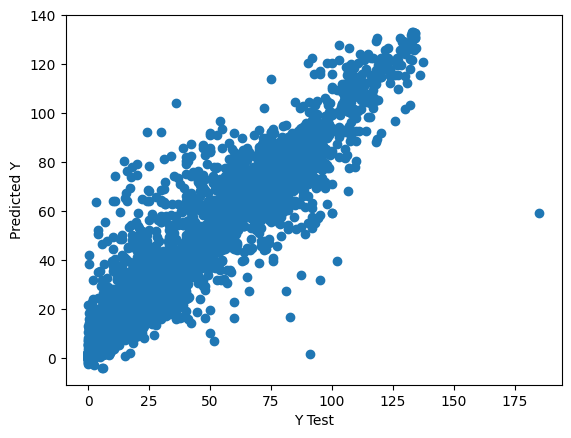

In [27]:
print('MAE:', mean_absolute_error(y_test, predictions3))
print('MSE:', mean_squared_error(y_test, predictions3))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions3)))
print('r^2:', r2_score(y_test, predictions3))
plt.scatter(y_test,predictions3)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
print(y_test, predictions3)

MAE: 7.664827403684991
MSE: 138.12288631913682
RMSE: 11.752569349684213
r^2: 0.8809999075577336
13976     6.40
1710     91.20
369      38.00
1698     19.00
13540    11.00
         ...  
9260     43.00
13177     4.24
12425     6.43
13908    14.90
533      92.20
Name: critical_temp, Length: 6379, dtype: float64 [ 7.64500217 86.71618759 52.83304497 ...  3.39080066 12.49008845
 89.52995194]


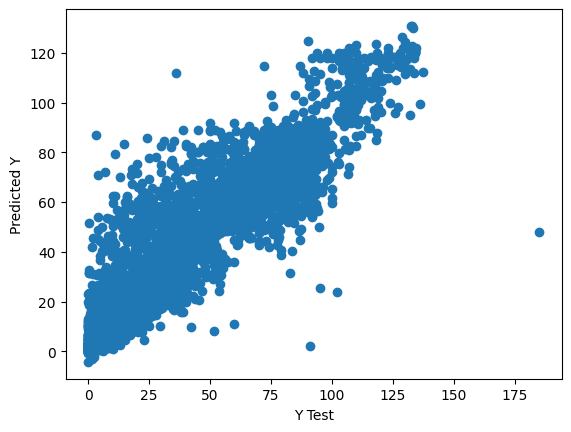

In [28]:
from sklearn.ensemble import GradientBoostingRegressor






GBR_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3
)

GBR_model.fit(X_train, y_train)

predictions4 = GBR_model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, predictions4))
print('MSE:', mean_squared_error(y_test, predictions4))
print('RMSE:', np.sqrt(mean_squared_error(y_test, predictions4)))
print('r^2:', r2_score(y_test, predictions4))
plt.scatter(y_test,predictions4)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
print(y_test, predictions4)